## Naloga 4: Odprta naloga

V datoteki `dn3_cracked.csv` je podana podatkovna množica, kjer primeri ustrezajo študentom. Tvoja naloga je sestaviti napovedni model, ki glede na smiselno izbrano metriko čim bolje napove, ali je študent študij končal, ga še vedno opravlja, ali je s študijem prenehal (to so vrednosti v zadnjem stolpcu z naslovom `Target`).

Celoten postopek in vse poskuse (tudi neuspešne) zabeleži in o njih poročaj.

> Pozor: Ne predpostavljaj, da so podatki čisti. Izbira mere uspešnosti, postopek delitve podatkov in obravnava razredne neuravnoteženosti so del naloge — vse svoje odločitve dobro premisli in tudi pisno utemelji v oddani rešitvi.

Podatkovna množica vsebuje naslednje spremenljivke:

- Zakonski stan: kategorični
- Vrsta vloge: kategoričen
- Vrstni red vloge: int
- Tečaj: kategoričen
- Prisotnost podnevi/zvečer: kategorična
- Prejšnja kvalifikacija: kategorična
- Prejšnja kvalifikacija (ocena): float
- Državljanstvo: kategorialno
- Materina kvalifikacija: kategorična
- Očetova kvalifikacija: kategorična
- Poklic matere: kategoričen
- Poklic očeta: kategoričen
- Ocena pri vpisu: float
- Preseljen: kategorično
- Posebne izobraževalne potrebe: kategorično
- Dolžnik: kategorično
- Šolnine do datuma: kategorično
- Spol: kategorično
- Zadnje tri številke študentske izkaznice: int
- Štipendist: kategorično
- Starost ob vpisu: int
- Tujec: kategorično
- Učne enote 1. semester (priznane): int
- Učne enote 1. semester (vpisane): int
- Učne enote 1. semester (ocene): int
- Učne enote 1. semester (odobrene): int
- Učne enote 1. semester (ocena): float
- Učne enote 1. semester (brez ocen): int
- Učne enote 2. semester (priznane): int
- Učne enote 2. semester (vpisane): int
- Učne enote 2. semester (ocene): int
- Učne enote 2. semester (odobrene): int
- Učne enote 2. semester (ocena): float
- Učne enote 2. semester (brez ocen): int
- Stopnja brezposelnosti: float
- Stopnja inflacije: float
- BDP: float
- Standardiziran rezultat sprejemnega testa: float
- Indeks socioekonomskega statusa: float
- Anketni rezultat zadovoljstva: float
- Povprečna ocena srednje šole (normalizirana): float
- Indeks oddaljenosti od fakultete: float
- Mesečni dohodek staršev (z-score): float
- Rezultat psihološkega testa A: float
- Rezultat psihološkega testa B: float
- Indeks delovne obremenitve: float
- Število ur učenja na teden (z-score): float
- Indeks digitalne pismenosti: float
- Rezultat preverjanja angleščine: float
- Ocena motivacijskega pisma: float
- Indeks zdravstvenega stanja: float
- Rezultat testa logičnega sklepanja: float
- Številka prijave: int
- Šifra mentorja: int
- Številka razreda v srednji šoli: int
- Poštna številka: int
- Šifra študijskega programa: int
- Ciljna vrednost (`Target`): kategoričen


## Audit podatkov

Spodnje celice podatke samo berejo in povzemajo. Ne izvajajo čiščenja, imputacije, kodiranja, delitve podatkov ali modeliranja. Ker CSV nima lastnih podatkovnih tipov, audit poleg surovega zapisa prikaže še pričakovani tip iz navodil in tip, ki ga je mogoče sklepati iz nepraznih vrednosti.

In [1]:
from pathlib import Path
import csv
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from html import escape
from IPython.display import display, HTML

DATA_PATH = Path("dn3_cracked.csv")
MISSING_MARKERS = {"", "na", "n/a", "nan", "null", "none", "?"}

df = pd.read_csv(DATA_PATH, sep=";")

with DATA_PATH.open(encoding="utf-8-sig", newline="") as handle:
    reader = csv.DictReader(handle, delimiter=";")
    columns = list(reader.fieldnames or [])
    rows = list(reader)

def is_missing(value):
    return value is None or value.strip().lower() in MISSING_MARKERS

def as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

def show_table(records, columns_to_show=None):
    records = list(records)
    if not records:
        display(HTML("<em>Ni vrstic za prikaz.</em>"))
        return
    columns_to_show = columns_to_show or list(records[0])
    header = "".join(f"<th>{escape(str(col))}</th>" for col in columns_to_show)
    body = []
    for record in records:
        cells = "".join(
            f"<td>{escape(str(record.get(col, '')))}</td>" for col in columns_to_show
        )
        body.append(f"<tr>{cells}</tr>")
    table = (
        "<div style='overflow-x:auto; max-height:520px'>"
        "<table><thead><tr>" + header + "</tr></thead><tbody>"
        + "".join(body) + "</tbody></table></div>"
    )
    display(HTML(table))

EXPECTED_CATEGORICAL = {
    "Marital status", "Application mode", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nationality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International", "Target"
}
EXPECTED_INTEGER = {
    "Application order", "Last three digits of the ID", "Age at enrollment",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (without evaluations)", "Application number",
    "Mentor code", "High school class number", "Postal code",
    "Study program code"
}
EXPECTED_FLOAT = set(columns) - EXPECTED_CATEGORICAL - EXPECTED_INTEGER
EXPECTED_TYPE = {
    **{col: "kategoričen" for col in EXPECTED_CATEGORICAL},
    **{col: "int" for col in EXPECTED_INTEGER},
    **{col: "float" for col in EXPECTED_FLOAT},
}

assert columns and columns[-1] == "Target", "Pričakovani zadnji stolpec Target manjka."
assert set(columns) == set(EXPECTED_TYPE), "Shema CSV-ja se ne ujema s shemo iz navodil."
assert df.shape == (len(rows), len(columns)), "Pandas in surovi bralnik se ne ujemata."
print(f"Naložena datoteka: {DATA_PATH.resolve()}")
print("Podatki so v `df`; ločen surovi pogled se uporablja samo za dodatna preverjanja.")
print("Nobena auditna celica ne spreminja datoteke ali vrednosti v `df`.")

Naložena datoteka: C:\Users\Brus\Documents\Faks\ITAP\dn3_cracked.csv
Podatki so v `df`; ločen surovi pogled se uporablja samo za dodatna preverjanja.
Nobena auditna celica ne spreminja datoteke ali vrednosti v `df`.


### 1. Oblika podatkov

In [2]:
print(f"Oblika (vrstice, stolpci): ({len(rows)}, {len(columns)})")
print(f"Število primerov: {len(rows)}")
print(f"Število napovednih stolpcev: {len(columns) - 1}")
print(f"Ciljni stolpec: {columns[-1]}")
print(f"Podvojena imena stolpcev: {len(columns) - len(set(columns))}")

Oblika (vrstice, stolpci): (1875, 58)
Število primerov: 1875
Število napovednih stolpcev: 57
Ciljni stolpec: Target
Podvojena imena stolpcev: 0


### 2. Tipi stolpcev

`Tip v CSV` je vedno besedilni zapis. `Sklepani logični tip` temelji samo na nepraznih vrednostih; kodirane kategorične spremenljivke ostajajo kategorične, četudi so zapisane s številkami.

In [3]:
type_rows = []
for column in columns:
    present = [row[column] for row in rows if not is_missing(row[column])]
    parsed = [as_float(value) for value in present]
    parsing_failures = sum(value is None for value in parsed)
    non_finite = sum(value is not None and not math.isfinite(value) for value in parsed)
    if column == "Target":
        inferred = "besedilo / kategorija"
    elif parsing_failures or non_finite:
        inferred = "mešano ali neštevilsko"
    elif all(value.is_integer() for value in parsed):
        inferred = "celoštevilsko kodirano" if column in EXPECTED_CATEGORICAL else "celoštevilsko"
    else:
        inferred = "število s plavajočo vejico"
    type_rows.append({
        "Stolpec": column,
        "Tip v CSV": "str",
        "Pričakovani tip": EXPECTED_TYPE[column],
        "Sklepani logični tip": inferred,
        "Neprazne vrednosti": len(present),
        "Napake pri številskem branju": parsing_failures if column != "Target" else "—",
    })
show_table(type_rows)

Stolpec,Tip v CSV,Pričakovani tip,Sklepani logični tip,Neprazne vrednosti,Napake pri številskem branju
Curricular units 2nd sem (enrolled),str,int,celoštevilsko,1654,0
Scholarship holder,str,kategoričen,celoštevilsko kodirano,1661,0
Curricular units 2nd sem (approved),str,int,celoštevilsko,1661,0
Logical reasoning test score,str,float,število s plavajočo vejico,1875,0
Debtor,str,kategoričen,celoštevilsko kodirano,1667,0
Mother's occupation,str,kategoričen,celoštevilsko kodirano,1665,0
Mother's qualification,str,kategoričen,celoštevilsko kodirano,1665,0
Application order,str,int,celoštevilsko,1666,0
Digital literacy index,str,float,število s plavajočo vejico,1875,0
Admission grade,str,float,število s plavajočo vejico,1650,0


### 3. Porazdelitev `Target`

In [4]:
target_values = ["<MANJKA>" if is_missing(row["Target"]) else row["Target"] for row in rows]
target_counts = Counter(target_values)
target_rows = [
    {
        "Razred": label,
        "Število": count,
        "Delež": f"{100 * count / len(rows):.2f}%",
    }
    for label, count in target_counts.most_common()
]
if "<MANJKA>" not in target_counts:
    target_rows.append({"Razred": "<MANJKA>", "Število": 0, "Delež": "0.00%"})
show_table(target_rows)
largest = max(target_counts.values())
smallest_nonzero = min(count for count in target_counts.values() if count > 0)
print(f"Razmerje med največjim in najmanjšim prisotnim razredom: {largest / smallest_nonzero:.2f} : 1")

Razred,Število,Delež
Dropout,1406,74.99%
Enrolled,375,20.00%
Graduate,94,5.01%
<MANJKA>,0,0.00%


Razmerje med največjim in najmanjšim prisotnim razredom: 14.96 : 1


### 4. Manjkajoče vrednosti

Kot manjkajoče se štejejo prazna polja in običajne oznake `NA`, `N/A`, `NaN`, `null`, `none` ter `?` (neobčutljivo na velikost črk).

In [5]:
missing_rows = []
for column in columns:
    count = sum(is_missing(row[column]) for row in rows)
    missing_rows.append({
        "Stolpec": column,
        "Manjka": count,
        "Delež": f"{100 * count / len(rows):.2f}%",
    })
missing_rows.sort(key=lambda record: (-record["Manjka"], record["Stolpec"]))
show_table(missing_rows)
total_missing = sum(record["Manjka"] for record in missing_rows)
total_cells = len(rows) * len(columns)
columns_with_missing = sum(record["Manjka"] > 0 for record in missing_rows)
print(f"Skupaj manjka {total_missing} od {total_cells} celic ({100 * total_missing / total_cells:.2f}%).")
print(f"Stolpci z vsaj eno manjkajočo vrednostjo: {columns_with_missing} od {len(columns)}.")

Stolpec,Manjka,Delež
Admission grade,225,12.00%
Daytime/evening attendance,223,11.89%
Curricular units 2nd sem (credited),222,11.84%
Curricular units 2nd sem (enrolled),221,11.79%
Curricular units 1st sem (grade),220,11.73%
Curricular units 2nd sem (evaluations),219,11.68%
Course,218,11.63%
Gender,217,11.57%
Application mode,216,11.52%
Father's qualification,215,11.47%


Skupaj manjka 8415 od 108750 celic (7.74%).
Stolpci z vsaj eno manjkajočo vrednostjo: 40 od 58.


### 5. Duplikati

Preverjanje je izvedeno na celotnih surovih vrsticah, zato so duplikati samo popolnoma enaki zapisi v vseh 58 stolpcih.

In [6]:
signatures = [tuple(row[column] for column in columns) for row in rows]
signature_counts = Counter(signatures)
duplicate_excess = sum(count - 1 for count in signature_counts.values() if count > 1)
duplicate_groups = sum(count > 1 for count in signature_counts.values())
print(f"Popolnoma podvojene vrstice (brez prve pojavitve): {duplicate_excess}")
print(f"Skupine podvojenih vrstic: {duplicate_groups}")
print(f"Podvojena imena stolpcev: {len(columns) - len(set(columns))}")

Popolnoma podvojene vrstice (brez prve pojavitve): 0
Skupine podvojenih vrstic: 0
Podvojena imena stolpcev: 0


### 6. Neveljavne in notranje nedosledne vrednosti

Spodnja pravila so namenoma konservativna: preverjajo le zanesljivo določljive napake iz navodil in osnovne notranje relacije. Manjkajoče vrednosti se poročajo ločeno in tu niso označene kot neveljavne. Brez uradnega šifranta ni mogoče zanesljivo presoditi, ali je posamezna številčna koda kategorije dovoljena.

In [7]:
validation_results = []

def add_validation(rule, failures):
    failures = list(failures)
    validation_results.append({
        "Pravilo": rule,
        "Kršitve": len(failures),
        "Primeri": "; ".join(failures[:5]) if failures else "—",
    })

numeric_columns = set(columns) - {"Target"}
failures = []
for csv_row, row in enumerate(rows, start=2):
    for column in numeric_columns:
        if is_missing(row[column]):
            continue
        value = as_float(row[column])
        if value is None:
            failures.append(f"vrstica {csv_row}, {column}={row[column]!r}")
add_validation("Neštevilski zapis v številskem ali številčno kodiranem stolpcu", failures)

failures = []
for csv_row, row in enumerate(rows, start=2):
    for column in numeric_columns:
        if is_missing(row[column]):
            continue
        value = as_float(row[column])
        if value is not None and not math.isfinite(value):
            failures.append(f"vrstica {csv_row}, {column}={row[column]!r}")
add_validation("Neskončna ali NaN številska vrednost", failures)

integer_like_columns = EXPECTED_INTEGER | (EXPECTED_CATEGORICAL - {"Target"})
failures = []
for csv_row, row in enumerate(rows, start=2):
    for column in integer_like_columns:
        if is_missing(row[column]):
            continue
        value = as_float(row[column])
        if value is not None and math.isfinite(value) and not value.is_integer():
            failures.append(f"vrstica {csv_row}, {column}={row[column]!r}")
add_validation("Necela vrednost v celoštevilskem ali kategorično kodiranem stolpcu", failures)

allowed_targets = {"Dropout", "Enrolled", "Graduate"}
failures = [
    f"vrstica {csv_row}, Target={row['Target']!r}"
    for csv_row, row in enumerate(rows, start=2)
    if not is_missing(row["Target"]) and row["Target"] not in allowed_targets
]
add_validation("Target ni eden od Dropout, Enrolled, Graduate", failures)

binary_columns = {
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender",
    "Scholarship holder", "International"
}
failures = []
for csv_row, row in enumerate(rows, start=2):
    for column in binary_columns:
        if is_missing(row[column]):
            continue
        value = as_float(row[column])
        if value is not None and value not in {0.0, 1.0}:
            failures.append(f"vrstica {csv_row}, {column}={row[column]!r}")
add_validation("Nebinarna vrednost v binarnem stolpcu", failures)

grade_columns = {
    "Previous qualification (grade)", "Admission grade",
    "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)"
}
nonnegative_columns = EXPECTED_INTEGER | (EXPECTED_CATEGORICAL - {"Target"}) | grade_columns | {"Unemployment rate"}
failures = []
for csv_row, row in enumerate(rows, start=2):
    for column in nonnegative_columns:
        if is_missing(row[column]):
            continue
        value = as_float(row[column])
        if value is not None and math.isfinite(value) and value < 0:
            failures.append(f"vrstica {csv_row}, {column}={row[column]!r}")
add_validation("Negativna vrednost v stolpcu, ki mora biti nenegativen", failures)

bounds = {
    "Age at enrollment": (15, 100),
    "Last three digits of the ID": (0, 999),
    "Admission grade": (0, 200),
    "Previous qualification (grade)": (0, 200),
    "Curricular units 1st sem (grade)": (0, 20),
    "Curricular units 2nd sem (grade)": (0, 20),
    "Unemployment rate": (0, 100),
}
failures = []
for csv_row, row in enumerate(rows, start=2):
    for column, (lower, upper) in bounds.items():
        if is_missing(row[column]):
            continue
        value = as_float(row[column])
        if value is not None and math.isfinite(value) and not lower <= value <= upper:
            failures.append(f"vrstica {csv_row}, {column}={row[column]!r}, meja=[{lower}, {upper}]")
add_validation("Vrednost zunaj konservativnih stvarnih meja", failures)

failures = []
for csv_row, row in enumerate(rows, start=2):
    for semester in ("1st", "2nd"):
        enrolled_col = f"Curricular units {semester} sem (enrolled)"
        for kind in ("approved", "credited"):
            compared_col = f"Curricular units {semester} sem ({kind})"
            if is_missing(row[enrolled_col]) or is_missing(row[compared_col]):
                continue
            enrolled = as_float(row[enrolled_col])
            compared = as_float(row[compared_col])
            if enrolled is not None and compared is not None and compared > enrolled:
                failures.append(
                    f"vrstica {csv_row}, {compared_col}={compared:g} > {enrolled_col}={enrolled:g}"
                )
add_validation("Odobrene ali priznane enote presegajo vpisane enote", failures)

show_table(validation_results)
print(f"Skupno število kršitev navedenih pravil: {sum(item['Kršitve'] for item in validation_results)}")

Pravilo,Kršitve,Primeri
Neštevilski zapis v številskem ali številčno kodiranem stolpcu,0,—
Neskončna ali NaN številska vrednost,0,—
Necela vrednost v celoštevilskem ali kategorično kodiranem stolpcu,0,—
"Target ni eden od Dropout, Enrolled, Graduate",0,—
Nebinarna vrednost v binarnem stolpcu,0,—
"Negativna vrednost v stolpcu, ki mora biti nenegativen",0,—
Vrednost zunaj konservativnih stvarnih meja,0,—
Odobrene ali priznane enote presegajo vpisane enote,0,—


Skupno število kršitev navedenih pravil: 0


### 7. Kardinalnost

Kardinalnost je število različnih nepraznih vrednosti. Visoka kardinalnost je pri zveznih meritvah pričakovana; sama po sebi zato še ne pomeni, da je stolpec identifikator.

In [8]:
cardinality_rows = []
for column in columns:
    present = [row[column] for row in rows if not is_missing(row[column])]
    counts = Counter(present)
    unique_count = len(counts)
    dominant_count = max(counts.values()) if counts else 0
    cardinality_rows.append({
        "Stolpec": column,
        "Različne neprazne": unique_count,
        "Neprazne": len(present),
        "Razmerje enoličnosti": f"{unique_count / len(present):.4f}" if present else "—",
        "Največja frekvenca ene vrednosti": dominant_count,
    })
cardinality_rows.sort(
    key=lambda record: (-record["Različne neprazne"], record["Stolpec"])
)
show_table(cardinality_rows)

Stolpec,Različne neprazne,Neprazne,Razmerje enoličnosti,Največja frekvenca ene vrednosti
Digital literacy index,1875,1875,1.0000,1
Distance to faculty index,1875,1875,1.0000,1
English proficiency test score,1875,1875,1.0000,1
Health status index,1875,1875,1.0000,1
High school GPA (normalized),1875,1875,1.0000,1
Logical reasoning test score,1875,1875,1.0000,1
Motivation letter score,1875,1875,1.0000,1
Parents' monthly income (z-score),1875,1875,1.0000,1
Psychological test A score,1875,1875,1.0000,1
Satisfaction survey score,1875,1875,1.0000,1


### 8. Možni identifikatorji

Kandidati so izbrani po pomenu imena (`ID`, `number`, `code`, `postal`, `digits`) in nato opisani z enoličnostjo. Gre za opozorilo za kasnejšo presojo, ne za samodejno odločitev o odstranitvi stolpca.

In [9]:
identifier_cues = (" id", "number", "code", "postal", "digits")
identifier_rows = []
for column in columns:
    normalized_name = " " + column.lower()
    if not any(cue in normalized_name for cue in identifier_cues):
        continue
    present = [row[column] for row in rows if not is_missing(row[column])]
    counts = Counter(present)
    unique_count = len(counts)
    ratio = unique_count / len(present) if present else 0
    duplicate_excess = sum(count - 1 for count in counts.values() if count > 1)
    reason = "ime nakazuje identifikator"
    if ratio >= 0.95:
        reason += "; skoraj vsaka neprazna vrednost je enolična"
    else:
        reason += "; lahko gre za delni ali skupinski identifikator"
    identifier_rows.append({
        "Stolpec": column,
        "Manjka": len(rows) - len(present),
        "Različne neprazne": unique_count,
        "Razmerje enoličnosti": f"{ratio:.4f}",
        "Ponovitve nad prvo pojavitvijo": duplicate_excess,
        "Razlog za opozorilo": reason,
    })
identifier_rows.sort(
    key=lambda record: (-float(record["Razmerje enoličnosti"]), record["Stolpec"])
)
show_table(identifier_rows)

Stolpec,Manjka,Različne neprazne,Razmerje enoličnosti,Ponovitve nad prvo pojavitvijo,Razlog za opozorilo
High school class number,0,1860,0.9920,15,ime nakazuje identifikator; skoraj vsaka neprazna vrednost je enolična
Postal code,0,1859,0.9915,16,ime nakazuje identifikator; skoraj vsaka neprazna vrednost je enolična
Mentor code,187,1673,0.9911,15,ime nakazuje identifikator; skoraj vsaka neprazna vrednost je enolična
Application number,0,1856,0.9899,19,ime nakazuje identifikator; skoraj vsaka neprazna vrednost je enolična
Study program code,0,1853,0.9883,22,ime nakazuje identifikator; skoraj vsaka neprazna vrednost je enolična
Last three digits of the ID,187,100,0.0592,1588,ime nakazuje identifikator; lahko gre za delni ali skupinski identifikator


## 1. faza: dokončanje audita in pravila čiščenja

Naslednje celice dopolnijo začetni audit s kontrolami iz delovnega načrta in določijo sezname stolpcev za poznejši pipeline. Še vedno ne imputirajo, ne kodirajo in ne učijo modelov.

### 9. Pandas pregled

Ta celica neposredno pokaže prvih pet vrstic in tipe, kot jih je razbral `pd.read_csv`.

In [10]:
print(f"df.shape = {df.shape}")
display(df.head())
df.info()

df.shape = (1875, 58)


,Curricular units 2nd sem (enrolled),Scholarship holder,Curricular units 2nd sem (approved),Logical reasoning test score,Debtor,Mother's occupation,Mother's qualification,Application order,Digital literacy index,Admission grade,...,High school class number,Satisfaction survey score,Previous qualification,Age at enrollment,English proficiency test score,Postal code,Workload index,Educational special needs,Unemployment rate,Target
0,NaN,0.0,0.0,1.029202,0.0,4.0,1.0,2.0,0.497645,115.2,...,64857,-0.041278,1.0,21.0,-1.518980,16423,0.155148,1.0,15.5,Dropout
1,8.0,1.0,0.0,0.825069,NaN,9.0,19.0,1.0,-0.116446,125.8,...,79290,-1.053710,1.0,20.0,-0.536819,26941,0.386800,0.0,9.4,Enrolled
2,6.0,0.0,0.0,0.321814,0.0,9.0,19.0,2.0,2.255744,122.8,...,40883,-0.400564,NaN,19.0,1.384662,53610,0.499483,0.0,12.4,Dropout
3,NaN,0.0,2.0,0.232663,0.0,9.0,38.0,3.0,1.159216,127.3,...,69679,-0.675953,1.0,19.0,0.220975,11437,-0.343901,0.0,12.7,Dropout
4,8.0,NaN,8.0,-0.036289,0.0,3.0,NaN,1.0,0.816734,142.8,...,69075,-0.796558,NaN,18.0,-0.774695,62987,0.183969,0.0,NaN,Graduate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 58 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Curricular units 2nd sem (enrolled)             1654 non-null   float64
 1   Scholarship holder                              1661 non-null   float64
 2   Curricular units 2nd sem (approved)             1661 non-null   float64
 3   Logical reasoning test score                    1875 non-null   float64
 4   Debtor                                          1667 non-null   float64
 5   Mother's occupation                             1665 non-null   float64
 6   Mother's qualification                          1665 non-null   float64
 7   Application order                               1666 non-null   float64
 8   Digital literacy index                          1875 non-null   float64
 9   Admission grade                          

### 10. Dopolnilne kontrole manjkajočnosti in duplikatov

Poleg popolnih duplikatov preverimo še dvojnike z enakimi 57 napovednimi spremenljivkami. Izmerimo tudi, koliko vrstic bi ostalo po naivnem brisanju vseh nepopolnih primerov.

In [11]:
predictor_columns = [column for column in df.columns if column != "Target"]
predictor_missing = df[predictor_columns].isna().sum()
affected_missing = predictor_missing[predictor_missing > 0]
complete_rows = int(df[predictor_columns].notna().all(axis=1).sum())
incomplete_rows = len(df) - complete_rows
duplicate_predictors = int(df.duplicated(subset=predictor_columns).sum())

control_rows = [
    {"Preverjanje": "Vrstice brez manjkajočih napovednih vrednosti", "Rezultat": complete_rows},
    {"Preverjanje": "Vrstice z vsaj eno manjkajočo napovedno vrednostjo", "Rezultat": incomplete_rows},
    {"Preverjanje": "Delež vrstic, ki bi jih odstranil dropna", "Rezultat": f"{100 * incomplete_rows / len(df):.2f}%"},
    {"Preverjanje": "Napovedni stolpci z manjkajočimi vrednostmi", "Rezultat": f"{len(affected_missing)} od {len(predictor_columns)}"},
    {"Preverjanje": "Razpon NaN na prizadeti stolpec", "Rezultat": f"{int(affected_missing.min())}–{int(affected_missing.max())}"},
    {"Preverjanje": "Razpon deleža NaN na prizadeti stolpec", "Rezultat": f"{100 * affected_missing.min() / len(df):.2f}%–{100 * affected_missing.max() / len(df):.2f}%"},
    {"Preverjanje": "Duplikati po vseh 58 stolpcih", "Rezultat": int(df.duplicated().sum())},
    {"Preverjanje": "Duplikati po 57 napovednih stolpcih", "Rezultat": duplicate_predictors},
]
show_table(control_rows)

predictor_cells = len(df) * len(predictor_columns)
predictor_missing_total = int(predictor_missing.sum())
print(f"Manjka {predictor_missing_total} od {predictor_cells} napovednih celic ({100 * predictor_missing_total / predictor_cells:.2f}%).")
print(f"Če v imenovalec vključimo tudi popolni Target, je delež {100 * predictor_missing_total / df.size:.2f}%.")

assert complete_rows == 18 and incomplete_rows == 1857
assert predictor_missing_total == 8415 and len(affected_missing) == 40
assert (int(affected_missing.min()), int(affected_missing.max())) == (187, 225)
assert duplicate_predictors == 0

Preverjanje,Rezultat
Vrstice brez manjkajočih napovednih vrednosti,18
Vrstice z vsaj eno manjkajočo napovedno vrednostjo,1857
"Delež vrstic, ki bi jih odstranil dropna",99.04%
Napovedni stolpci z manjkajočimi vrednostmi,40 od 57
Razpon NaN na prizadeti stolpec,187–225
Razpon deleža NaN na prizadeti stolpec,9.97%–12.00%
Duplikati po vseh 58 stolpcih,0
Duplikati po 57 napovednih stolpcih,0


Manjka 8415 od 106875 napovednih celic (7.87%).
Če v imenovalec vključimo tudi popolni Target, je delež 7.74%.


### 11. Grafični pregled razredov in manjkajočnosti

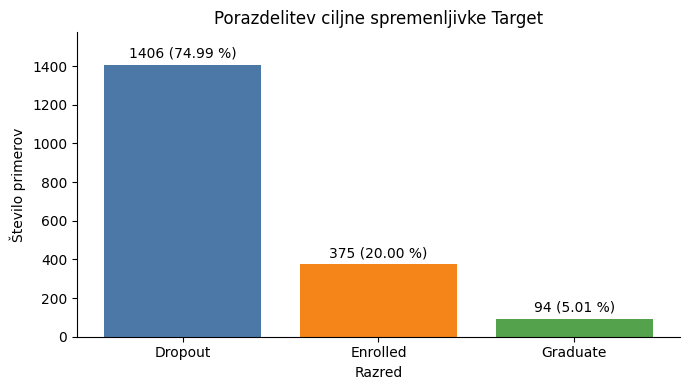

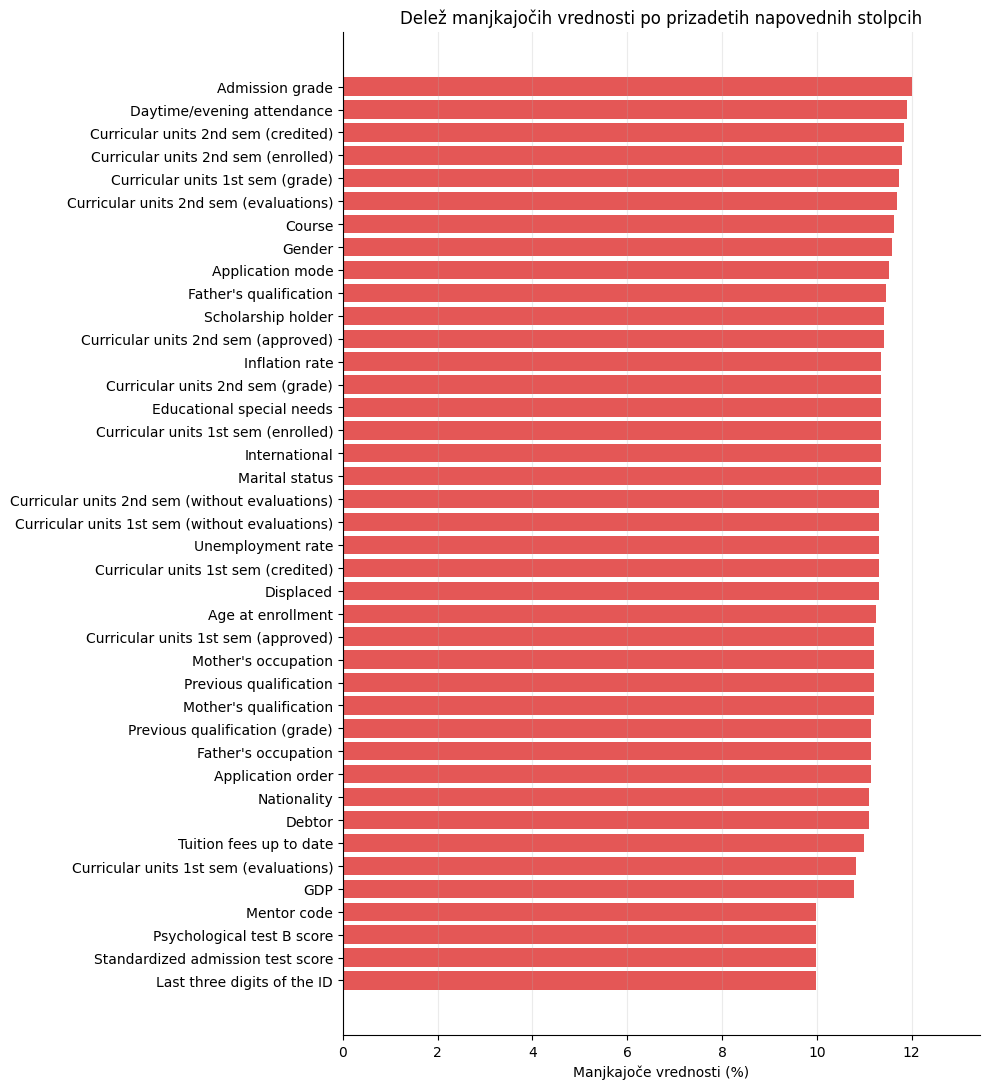

In [12]:
target_order = ["Dropout", "Enrolled", "Graduate"]
target_plot = df["Target"].value_counts().reindex(target_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(target_plot.index, target_plot.values, color=["#4C78A8", "#F58518", "#54A24B"])
ax.bar_label(
    bars,
    labels=[f"{count} ({100 * count / len(df):.2f} %)" for count in target_plot.values],
    padding=3,
)
ax.set(title="Porazdelitev ciljne spremenljivke Target", xlabel="Razred", ylabel="Število primerov")
ax.set_ylim(0, max(target_plot.values) * 1.12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

missing_share = (df[predictor_columns].isna().mean() * 100)
missing_share = missing_share[missing_share > 0].sort_values()
fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(missing_share.index, missing_share.values, color="#E45756")
ax.set(
    title="Delež manjkajočih vrednosti po prizadetih napovednih stolpcih",
    xlabel="Manjkajoče vrednosti (%)",
    ylabel="",
)
ax.set_xlim(0, max(missing_share.values) * 1.12)
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Pravila čiščenja in obseg podatkov po 1. fazi

- **Manjkajoče vrednosti:** vrstic ne brišemo, saj bi ostalo samo 18 primerov. V poznejšem `Pipeline` bomo numerične vrednosti imputirali z mediano in indikatorji manjkajočnosti, kategorične pa z modusom ali posebno oznako. Do takrat `df` ostane nespremenjen.
- **Duplikati:** ker ni popolnih duplikatov niti dvojnikov z enakimi napovednimi spremenljivkami, ne odstranimo ničesar.
- **Identifikatorji:** spodnjih šest stolpcev izločimo iz osnovnega nabora značilk. Surovih podatkov ne spreminjamo; seznam `BASE_FEATURE_COLUMNS` samo določa dovoljeni pogled za naslednje faze. Pozneje bomo vpliv ID-stolpcev preverili z ločeno ablacijsko kontrolo.
- **Kategorije:** 17 vsebinsko kategoričnih stolpcev bomo pozneje kodirali kot kategorije. `Course` ostane kategorija, ker ima le 17 različnih vrednosti in predstavlja dejanski študijski program.
- **Čas napovedi:** delovna primarna različica napoveduje status po koncu 2. semestra, zato semestrske spremenljivke za zdaj obdržimo. Kot vsebinsko kontrolo bomo pozneje poročali še zgodnjo različico samo s podatki, znanimi ob vpisu.
- **Cilj in metrika:** gre za neuravnoteženo večrazredno klasifikacijo; v naslednjih fazah bo primarna metrika `macro-F1`. Testna množica še ni ustvarjena in ni bila uporabljena.

In [13]:
CATEGORICAL_COLUMNS = [
    "Marital status", "Application mode", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nationality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International",
]
ID_COLUMNS = [
    "Application number", "High school class number", "Postal code",
    "Study program code", "Mentor code", "Last three digits of the ID",
]
BASE_FEATURE_COLUMNS = [
    column for column in predictor_columns if column not in ID_COLUMNS
]
NUMERIC_COLUMNS = [
    column for column in BASE_FEATURE_COLUMNS if column not in CATEGORICAL_COLUMNS
]

assert len(CATEGORICAL_COLUMNS) == 17
assert len(ID_COLUMNS) == 6
assert len(BASE_FEATURE_COLUMNS) == 51 and len(NUMERIC_COLUMNS) == 34
assert set(CATEGORICAL_COLUMNS).isdisjoint(ID_COLUMNS)
assert set(CATEGORICAL_COLUMNS + ID_COLUMNS).issubset(predictor_columns)
assert "Course" in CATEGORICAL_COLUMNS and "Course" not in ID_COLUMNS

column_group_rows = (
    [{"Skupina": "Kategorični (17)", "Stolpec": column} for column in CATEGORICAL_COLUMNS]
    + [{"Skupina": "Izločeni ID (6)", "Stolpec": column} for column in ID_COLUMNS]
)
show_table(column_group_rows)

id_profile_rows = []
for column in ID_COLUMNS:
    non_missing = int(df[column].notna().sum())
    unique = int(df[column].nunique(dropna=True))
    id_profile_rows.append({
        "ID-kandidat": column,
        "Različne neprazne": unique,
        "Enoličnost / vse vrstice": f"{unique / len(df):.4f}",
        "Enoličnost / neprazne": f"{unique / non_missing:.4f}",
    })
show_table(id_profile_rows)
print(f"Osnovni nabor: {len(BASE_FEATURE_COLUMNS)} značilk = {len(CATEGORICAL_COLUMNS)} kategoričnih + {len(NUMERIC_COLUMNS)} numeričnih.")

Skupina,Stolpec
Kategorični (17),Marital status
Kategorični (17),Application mode
Kategorični (17),Course
Kategorični (17),Daytime/evening attendance
Kategorični (17),Previous qualification
Kategorični (17),Nationality
Kategorični (17),Mother's qualification
Kategorični (17),Father's qualification
Kategorični (17),Mother's occupation
Kategorični (17),Father's occupation


ID-kandidat,Različne neprazne,Enoličnost / vse vrstice,Enoličnost / neprazne
Application number,1856,0.9899,0.9899
High school class number,1860,0.9920,0.9920
Postal code,1859,0.9915,0.9915
Study program code,1853,0.9883,0.9883
Mentor code,1673,0.8923,0.9911
Last three digits of the ID,100,0.0533,0.0592


Osnovni nabor: 51 značilk = 17 kategoričnih + 34 numeričnih.


## Ugotovitve audita

- Podatkovna množica ima **1.875 vrstic in 58 stolpcev**: 57 napovednih spremenljivk ter ciljni stolpec `Target`. Imena stolpcev se ne podvajajo.
- Vsi napovedni stolpci so v CSV-ju zapisani številčno oziroma s številčnimi kodami, `Target` pa besedilno. Neprazne vrednosti so skladne z osnovnimi tipi iz navodil: audit ni našel neštevilskih zapisov, neskončnosti ali neceloštevilskih vrednosti v celoštevilskih oziroma kategorično kodiranih stolpcih.
- `Target` nima manjkajočih ali neznanih oznak, vendar je **močno neuravnotežen**: `Dropout` 1.406 (74,99 %), `Enrolled` 375 (20,00 %) in `Graduate` 94 (5,01 %). Največji razred je približno 14,96-krat večji od najmanjšega.
- Manjka **8.415 napovednih vrednosti**: 7,87 % od 106.875 napovednih celic oziroma 7,74 % vseh 108.750 celic, če vključimo tudi popolni `Target`. Vsaj ena vrednost manjka v 40 od 57 napovednih stolpcev. Na prizadeti stolpec manjka od 187 (9,97 %) do 225 (12,00 %) vrednosti.
- Samo **18 vrstic** je brez manjkajočih napovednih vrednosti, 1.857 pa ima vsaj eno. Naivni `dropna` bi zato odstranil 99,04 % primerov in ga ne bomo uporabili.
- Popolnoma podvojenih vrstic ni; prav tako ni dvojnikov z enakimi 57 napovednimi spremenljivkami.
- Konservativna preverjanja niso našla neveljavnih vrednosti: dovoljeni razredi `Target`, binarne kode, celoštevilskost, končnost, nenegativnost izbranih spremenljivk, stvarne meje za starost in ocene ter relacije med vpisanimi, priznanimi in odobrenimi enotami so brez kršitev. To ne potrjuje veljavnosti posameznih kategoričnih kod, ker navodila ne vsebujejo njihovega uradnega šifranta.
- Iz osnovnega modelskega nabora bomo izločili šest možnih identifikatorjev oziroma kvazi-identifikatorjev: `Application number`, `High school class number`, `Postal code`, `Study program code`, `Mentor code` in `Last three digits of the ID`. Definiran je samo seznam stolpcev; `df` in CSV ostajata nespremenjena.
- Določenih je 17 vsebinsko kategoričnih in 34 numeričnih značilk v osnovnem naboru. `Course` ostane kategorija. Primarna časovna različica uporablja informacije do konca 2. semestra; zgodnja različica bo poznejša vsebinska kontrola.
- Več zveznih meritev ima kardinalnost 1.875, kar je pri zveznih podatkih pričakovano in samo po sebi ni dokaz identifikatorske vloge.

Prva faza je zaključena na ravni audita in pravil čiščenja. Ni bilo izvedeno nobeno nadomeščanje manjkajočih vrednosti, kodiranje, fizično izločanje stolpcev, delitev podatkov ali modeliranje; vse transformacije bodo v naslednjih fazah izvedene znotraj pipelinea.

## 2. faza: pošten eksperimentalni protokol

Testno množico izločimo enkrat na začetku in je ne uporabimo za izbiro modela, hiperparametrov ali predprocesiranja. Vse primerjave modelov bodo v naslednjih fazah potekale samo na učnem delu z vnaprej določenimi stratificiranimi foldi.

### 12. Enkratna stratificirana delitev 80/20

V `X` vključimo samo 51 značilk osnovnega nabora, zato šest ID-stolpcev ni prisotnih že pred delitvijo. `random_state=42` zagotavlja ponovljivost. Pregled velikosti in razredov testa ni ocenjevanje modela; po tej kontroli test ostane nedotaknjen do končne ocene.

In [14]:
from sklearn.model_selection import train_test_split, StratifiedKFold

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COLUMN = "Target"

X = df[BASE_FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

assert X_train.shape == (1500, 51) and X_test.shape == (375, 51)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_train.index) | set(X_test.index) == set(df.index)
assert not set(ID_COLUMNS) & set(X.columns)

split_rows = []
for split_name, split_y in (("Učenje", y_train), ("Zaklenjeni test", y_test)):
    counts = split_y.value_counts().reindex(["Dropout", "Enrolled", "Graduate"])
    for target_class, count in counts.items():
        split_rows.append({
            "Del": split_name,
            "Razred": target_class,
            "Število": int(count),
            "Delež znotraj dela": f"{100 * count / len(split_y):.2f}%",
        })
show_table(split_rows)

assert y_train.value_counts().to_dict() == {"Dropout": 1125, "Enrolled": 300, "Graduate": 75}
assert y_test.value_counts().to_dict() == {"Dropout": 281, "Enrolled": 75, "Graduate": 19}
print(f"Učni del: {X_train.shape}; zaklenjeni test: {X_test.shape}.")
print("Na testu ni bil učen, izbran ali ocenjen noben model.")

Del,Razred,Število,Delež znotraj dela
Učenje,Dropout,1125,75.00%
Učenje,Enrolled,300,20.00%
Učenje,Graduate,75,5.00%
Zaklenjeni test,Dropout,281,74.93%
Zaklenjeni test,Enrolled,75,20.00%
Zaklenjeni test,Graduate,19,5.07%


Učni del: (1500, 51); zaklenjeni test: (375, 51).
Na testu ni bil učen, izbran ali ocenjen noben model.


### 13. Fiksni stratificirani foldi in metrike

Modele bomo primerjali z istim `StratifiedKFold(5, shuffle=True, random_state=42)`. Primarna metrika je `macro-F1`; sekundarno bomo poročali uravnoteženo točnost, F1/recall po razredih in matriko zamenjav.

In [15]:
CV_SPLITTER = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
PRIMARY_METRIC = "f1_macro"
CV_SCORING = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
}
FINAL_REPORT_METRICS = [
    "macro-F1", "balanced accuracy", "F1 po razredih",
    "recall po razredih", "confusion matrix",
]

fold_rows = []
for fold, (fit_indices, validation_indices) in enumerate(CV_SPLITTER.split(X_train, y_train), start=1):
    fit_counts = y_train.iloc[fit_indices].value_counts()
    validation_counts = y_train.iloc[validation_indices].value_counts()
    fold_rows.append({
        "Fold": fold,
        "Učenje n": len(fit_indices),
        "Validacija n": len(validation_indices),
        "Validacija Dropout": int(validation_counts["Dropout"]),
        "Validacija Enrolled": int(validation_counts["Enrolled"]),
        "Validacija Graduate": int(validation_counts["Graduate"]),
    })
    assert fit_counts.to_dict() == {"Dropout": 900, "Enrolled": 240, "Graduate": 60}
    assert validation_counts.to_dict() == {"Dropout": 225, "Enrolled": 60, "Graduate": 15}
show_table(fold_rows)
print(f"Primarna metrika za izbiro modela: {PRIMARY_METRIC}.")

Fold,Učenje n,Validacija n,Validacija Dropout,Validacija Enrolled,Validacija Graduate
1,1200,300,225,60,15
2,1200,300,225,60,15
3,1200,300,225,60,15
4,1200,300,225,60,15
5,1200,300,225,60,15


Primarna metrika za izbiro modela: f1_macro.


### 14. Predprocesiranje znotraj `ColumnTransformer` in `Pipeline`

Kategorične stolpce imputiramo z najpogostejšo vrednostjo in one-hot kodiramo z `handle_unknown='ignore'`. Numerične stolpce imputiramo z mediano ter dodamo indikatorje manjkajočnosti; rezultat standardiziramo. Objekt `FULL_PREPROCESSOR` spodaj ostane neprilegan. Funkcija `build_model_pipeline` bo v naslednjih fazah vsak klasifikator povezala z novo kopijo predprocesiranja, zato se bodo vsi parametri učili samo znotraj posameznega učnega folda.

In [16]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_preprocessor(feature_columns):
    categorical = [column for column in CATEGORICAL_COLUMNS if column in feature_columns]
    numeric = [column for column in feature_columns if column not in categorical]

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_pipeline, categorical),
            ("numeric", numeric_pipeline, numeric),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

FULL_PREPROCESSOR = build_preprocessor(BASE_FEATURE_COLUMNS)

def build_model_pipeline(estimator, feature_columns=BASE_FEATURE_COLUMNS):
    return Pipeline([
        ("preprocessor", build_preprocessor(feature_columns)),
        ("model", estimator),
    ])

assert not hasattr(FULL_PREPROCESSOR, "transformers_")
print("FULL_PREPROCESSOR je definiran in še ni prilegan.")
print("Modelskih transformacij ne bomo izvajali zunaj pipelinea.")

FULL_PREPROCESSOR je definiran in še ni prilegan.
Modelskih transformacij ne bomo izvajali zunaj pipelinea.


### 15. Tehnični preizkus predprocesiranja samo na učnem delu

Za preverjanje izvedljivosti klon predprocesirnega pipelinea prilegamo na `X_train`. `X_test` se samo transformira z že naučenimi parametri; njegove vrednosti ne vplivajo na imputacijo, kategorije ali skaliranje. Klon je namenjen izključno preverjanju oblike in končnosti izhoda ter se ne bo uporabil za ocenjevanje modelov.

In [17]:
import numpy as np
from scipy import sparse

preprocessing_preview = Pipeline([
    ("preprocessor", clone(FULL_PREPROCESSOR)),
])
X_train_transformed = preprocessing_preview.fit_transform(X_train)
X_test_transformed = preprocessing_preview.transform(X_test)
output_feature_names = (
    preprocessing_preview.named_steps["preprocessor"].get_feature_names_out()
)

def transformed_is_finite(matrix):
    values = matrix.data if sparse.issparse(matrix) else np.asarray(matrix)
    return bool(np.isfinite(values).all())

assert X_train_transformed.shape[0] == len(X_train)
assert X_test_transformed.shape[0] == len(X_test)
assert X_train_transformed.shape[1] == X_test_transformed.shape[1] == len(output_feature_names)
assert transformed_is_finite(X_train_transformed)
assert transformed_is_finite(X_test_transformed)
assert not hasattr(FULL_PREPROCESSOR, "transformers_")

preview_rows = [
    {"Del": "Učenje", "Vhodna oblika": str(X_train.shape), "Izhodna oblika": str(X_train_transformed.shape)},
    {"Del": "Zaklenjeni test (samo transform)", "Vhodna oblika": str(X_test.shape), "Izhodna oblika": str(X_test_transformed.shape)},
]
show_table(preview_rows)
print(f"Predprocesiranje ustvari {len(output_feature_names)} značilk in nobene ne-končne vrednosti.")
print("Kanonični FULL_PREPROCESSOR ostaja neprilegan; fitted je samo diagnostični klon.")

Del,Vhodna oblika,Izhodna oblika
Učenje,"(1500, 51)","(1500, 237)"
Zaklenjeni test (samo transform),"(375, 51)","(375, 237)"


Predprocesiranje ustvari 237 značilk in nobene ne-končne vrednosti.
Kanonični FULL_PREPROCESSOR ostaja neprilegan; fitted je samo diagnostični klon.


### 16. Dve časovni različici značilk

`FULL_FEATURE_COLUMNS` predstavlja primarni model po koncu 2. semestra. Za konservativno zgodnjo različico poleg vseh semestrskih spremenljivk izločimo še zadovoljstvo, tedenske ure učenja in obremenitev, saj iz navodil ni razvidno, da bi bile te meritve znane že ob vpisu. Ta vsebinska predpostavka je izrecno zapisana in jo lahko pozneje popravimo, če dobimo natančen čas merjenja.

In [18]:
FULL_FEATURE_COLUMNS = list(BASE_FEATURE_COLUMNS)
SEMESTER_COLUMNS = [
    column for column in BASE_FEATURE_COLUMNS
    if column.startswith("Curricular units 1st sem")
    or column.startswith("Curricular units 2nd sem")
]
OTHER_POSSIBLY_POST_ENROLLMENT_COLUMNS = [
    "Satisfaction survey score",
    "Weekly study hours (z-score)",
    "Workload index",
]
EARLY_EXCLUDED_COLUMNS = SEMESTER_COLUMNS + OTHER_POSSIBLY_POST_ENROLLMENT_COLUMNS
EARLY_FEATURE_COLUMNS = [
    column for column in BASE_FEATURE_COLUMNS if column not in EARLY_EXCLUDED_COLUMNS
]

assert len(SEMESTER_COLUMNS) == 12
assert len(FULL_FEATURE_COLUMNS) == 51 and len(EARLY_FEATURE_COLUMNS) == 36
assert set(EARLY_FEATURE_COLUMNS).issubset(FULL_FEATURE_COLUMNS)
assert set(EARLY_EXCLUDED_COLUMNS).isdisjoint(EARLY_FEATURE_COLUMNS)

time_variant_rows = [
    {"Različica": "A – po 2. semestru", "Število značilk": len(FULL_FEATURE_COLUMNS), "Vloga": "primarna"},
    {"Različica": "B – zgodnja ob vpisu", "Število značilk": len(EARLY_FEATURE_COLUMNS), "Vloga": "vsebinska kontrola"},
]
show_table(time_variant_rows)
print("Iz zgodnje različice je izločenih:")
for column in EARLY_EXCLUDED_COLUMNS:
    print(f"- {column}")

Različica,Število značilk,Vloga
A – po 2. semestru,51,primarna
B – zgodnja ob vpisu,36,vsebinska kontrola


Iz zgodnje različice je izločenih:
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (approved)
- Curricular units 1st sem (credited)
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 2nd sem (without evaluations)
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (evaluations)
- Curricular units 1st sem (without evaluations)
- Curricular units 2nd sem (grade)
- Satisfaction survey score
- Weekly study hours (z-score)
- Workload index


## Ugotovitve 2. faze

- Enkratna stratificirana delitev z `random_state=42` je ustvarila **1.500 učnih** in **375 testnih** primerov. Učni del vsebuje 1.125 `Dropout`, 300 `Enrolled` in 75 `Graduate`; test vsebuje 281, 75 in 19 primerov.
- Testni indeksi se z učnimi ne prekrivajo. Test ni bil uporabljen za učenje, izbiro ali ocenjevanje modela.
- Pet fiksnih stratificiranih foldov ima vsak po 300 validacijskih primerov: 225 `Dropout`, 60 `Enrolled` in 15 `Graduate`.
- Primarna metrika je `macro-F1`; sekundarno bomo poročali uravnoteženo točnost, F1 in recall po razredih ter matriko zamenjav.
- Predprocesiranje je definirano v `ColumnTransformer`/`Pipeline`: modus in one-hot za 17 kategorij, mediana z indikatorji manjkajočnosti ter standardizacija za numerične značilke. Diagnostični klon je bil prilegan samo na učnem delu in je uspešno transformiral oba dela brez ne-končnih vrednosti.
- Definirani sta polna različica z 51 značilkami in konservativna zgodnja različica s 36 značilkami.

V 2. fazi ni bil učen noben klasifikator in na zaklenjenem testu ni bila izračunana nobena metrika uspešnosti.

## 3. faza: modeli in razredna neuravnoteženost

Vsi spodnji rezultati so dobljeni izključno na `X_train`/`y_train` z istimi petimi stratificiranimi foldi. Predprocesiranje in morebitno ponovno vzorčenje sta del pipelinea ter se v vsakem foldu prilegata samo na njegov učni poddel. Zaklenjeni test se v tej fazi ne uporablja.

### 17. Ocenjevalne funkcije

Poleg primarnega `macro-F1` beležimo uravnoteženo točnost ter F1 in recall vsakega razreda. Tako rezultat ne more skriti modela, ki zanemari mali razred `Graduate`. Standardni odklon je vzorčni odklon petih foldov (`ddof=1`).

In [19]:
from sklearn.metrics import f1_score, recall_score, make_scorer

CLASS_ORDER = ["Dropout", "Enrolled", "Graduate"]
PHASE3_SCORING = dict(CV_SCORING)
for target_class in CLASS_ORDER:
    scorer_suffix = target_class.lower()
    PHASE3_SCORING[f"f1_{scorer_suffix}"] = make_scorer(
        f1_score, labels=[target_class], average="macro", zero_division=0
    )
    PHASE3_SCORING[f"recall_{scorer_suffix}"] = make_scorer(
        recall_score, labels=[target_class], average="macro", zero_division=0
    )

print("Metrike:", ", ".join(PHASE3_SCORING))
assert "macro_f1" in PHASE3_SCORING and "f1_graduate" in PHASE3_SCORING

Metrike: macro_f1, balanced_accuracy, f1_dropout, recall_dropout, f1_enrolled, recall_enrolled, f1_graduate, recall_graduate


### 18. Kandidati in načini obravnave neuravnoteženosti

Primerjamo dva dummy modela, logistično regresijo, Extra Trees in HistGradientBoosting. Pri pravih modelih preverimo različici brez uteži in z `class_weight='balanced'`. SMOTENC je ločen eksperiment z logistično regresijo: najprej se znotraj folda imputirajo podatki, nato se ponovno vzorčijo numerične vrednosti in izvorne kategorije, one-hot kodiranje pa se izvede šele po SMOTENC. Indikatorji manjkajočnosti so pri vzorčenju označeni kot kategorije, zato ne nastanejo nesmiselne delne binarne kode.

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import MissingIndicator
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

def build_dense_model_pipeline(estimator, feature_columns=FULL_FEATURE_COLUMNS):
    categorical = [column for column in CATEGORICAL_COLUMNS if column in feature_columns]
    numeric = [column for column in feature_columns if column not in categorical]
    dense_preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), categorical),
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
            ]), numeric),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )
    return Pipeline([
        ("preprocessor", dense_preprocessor),
        ("model", estimator),
    ])

def build_smotenc_logistic_pipeline():
    numeric_indicators = [f"missingindicator_{column}" for column in NUMERIC_COLUMNS]
    smotenc_categorical = CATEGORICAL_COLUMNS + numeric_indicators

    pre_imputation = ColumnTransformer(
        transformers=[
            ("categorical", SimpleImputer(strategy="most_frequent"), CATEGORICAL_COLUMNS),
            ("numeric", SimpleImputer(strategy="median"), NUMERIC_COLUMNS),
            ("missing", MissingIndicator(features="all"), NUMERIC_COLUMNS),
        ],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")

    post_resampling = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), smotenc_categorical),
            ("numeric", StandardScaler(), NUMERIC_COLUMNS),
        ],
        remainder="drop",
    )

    return ImbPipeline([
        ("pre_imputation", pre_imputation),
        ("smotenc", SMOTENC(
            categorical_features=smotenc_categorical,
            sampling_strategy="not majority",
            k_neighbors=5,
            random_state=RANDOM_STATE,
        )),
        ("post_resampling", post_resampling),
        ("model", LogisticRegression(
            C=1.0, max_iter=3000, solver="lbfgs", random_state=RANDOM_STATE
        )),
    ])

EXPERIMENT_SPECS = [
    {"ID": "E00", "Model": "Dummy – most_frequent", "Uravnoteženje": "brez",
     "Pipeline": build_model_pipeline(DummyClassifier(strategy="most_frequent"))},
    {"ID": "E00S", "Model": "Dummy – stratified", "Uravnoteženje": "brez",
     "Pipeline": build_model_pipeline(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))},
    {"ID": "E01", "Model": "Logistična regresija", "Uravnoteženje": "brez",
     "Pipeline": build_model_pipeline(LogisticRegression(
         C=1.0, max_iter=3000, solver="lbfgs", random_state=RANDOM_STATE
     ))},
    {"ID": "E02", "Model": "Logistična regresija", "Uravnoteženje": "class_weight=balanced",
     "Pipeline": build_model_pipeline(LogisticRegression(
         C=1.0, max_iter=3000, solver="lbfgs", class_weight="balanced",
         random_state=RANDOM_STATE
     ))},
    {"ID": "E03", "Model": "Extra Trees", "Uravnoteženje": "brez",
     "Pipeline": build_model_pipeline(ExtraTreesClassifier(
         n_estimators=400, min_samples_leaf=2, max_features="sqrt",
         n_jobs=1, random_state=RANDOM_STATE
     ))},
    {"ID": "E04", "Model": "Extra Trees", "Uravnoteženje": "class_weight=balanced",
     "Pipeline": build_model_pipeline(ExtraTreesClassifier(
         n_estimators=400, min_samples_leaf=2, max_features="sqrt",
         class_weight="balanced", n_jobs=1, random_state=RANDOM_STATE
     ))},
    {"ID": "E05", "Model": "HistGradientBoosting", "Uravnoteženje": "brez",
     "Pipeline": build_dense_model_pipeline(HistGradientBoostingClassifier(
         learning_rate=0.05, max_iter=200, max_leaf_nodes=15, min_samples_leaf=20,
         random_state=RANDOM_STATE
     ))},
    {"ID": "E06", "Model": "HistGradientBoosting", "Uravnoteženje": "class_weight=balanced",
     "Pipeline": build_dense_model_pipeline(HistGradientBoostingClassifier(
         learning_rate=0.05, max_iter=200, max_leaf_nodes=15, min_samples_leaf=20,
         class_weight="balanced", random_state=RANDOM_STATE
     ))},
    {"ID": "E07", "Model": "Logistična regresija", "Uravnoteženje": "SMOTENC",
     "Pipeline": build_smotenc_logistic_pipeline()},
]

show_table([
    {key: spec[key] for key in ("ID", "Model", "Uravnoteženje")}
    for spec in EXPERIMENT_SPECS
])
assert len(EXPERIMENT_SPECS) == 9
assert all(not set(ID_COLUMNS) & set(X_train.columns) for _ in EXPERIMENT_SPECS)

ID,Model,Uravnoteženje
E00,Dummy – most_frequent,brez
E00S,Dummy – stratified,brez
E01,Logistična regresija,brez
E02,Logistična regresija,class_weight=balanced
E03,Extra Trees,brez
E04,Extra Trees,class_weight=balanced
E05,HistGradientBoosting,brez
E06,HistGradientBoosting,class_weight=balanced
E07,Logistična regresija,SMOTENC


### 19. Navzkrižno preverjanje vseh začetnih poskusov

Vsak poskus se zabeleži tudi ob napaki. Modeli se ne izvajajo vzporedno na ravni foldov (`n_jobs=1`), da se pri drevesih izognemo gnezdenemu paralelizmu in ohranimo predvidljivo porabo pomnilnika.

In [21]:
import time
from sklearn.model_selection import cross_validate

experiment_summary_rows = []
experiment_fold_rows = []

for spec in EXPERIMENT_SPECS:
    started = time.perf_counter()
    try:
        scores = cross_validate(
            spec["Pipeline"],
            X_train,
            y_train,
            cv=CV_SPLITTER,
            scoring=PHASE3_SCORING,
            n_jobs=1,
            return_train_score=False,
            error_score="raise",
        )
        elapsed = time.perf_counter() - started
        summary = {
            "ID": spec["ID"],
            "Model": spec["Model"],
            "Uravnoteženje": spec["Uravnoteženje"],
            "Status": "uspešno",
            "Čas (s)": elapsed,
        }
        for metric in PHASE3_SCORING:
            values = scores[f"test_{metric}"]
            summary[f"{metric}_mean"] = float(np.mean(values))
            summary[f"{metric}_std"] = float(np.std(values, ddof=1))
        experiment_summary_rows.append(summary)

        for fold in range(5):
            fold_row = {
                "ID": spec["ID"],
                "Fold": fold + 1,
            }
            for metric in PHASE3_SCORING:
                fold_row[metric] = float(scores[f"test_{metric}"][fold])
            experiment_fold_rows.append(fold_row)
        print(f"{spec['ID']}: macro-F1={summary['macro_f1_mean']:.3f} ± {summary['macro_f1_std']:.3f}")
    except Exception as error:
        elapsed = time.perf_counter() - started
        experiment_summary_rows.append({
            "ID": spec["ID"],
            "Model": spec["Model"],
            "Uravnoteženje": spec["Uravnoteženje"],
            "Status": "napaka",
            "Čas (s)": elapsed,
            "Napaka": f"{type(error).__name__}: {error}",
        })
        print(f"{spec['ID']}: NAPAKA – {type(error).__name__}: {error}")

experiment_summary = pd.DataFrame(experiment_summary_rows)
experiment_folds = pd.DataFrame(experiment_fold_rows)
assert len(experiment_summary) == len(EXPERIMENT_SPECS)
print(f"Uspešnih poskusov: {(experiment_summary['Status'] == 'uspešno').sum()} od {len(experiment_summary)}.")

E00: macro-F1=0.286 ± 0.000


E00S: macro-F1=0.352 ± 0.029


E01: macro-F1=0.548 ± 0.031


E02: macro-F1=0.550 ± 0.014


E03: macro-F1=0.384 ± 0.022


E04: macro-F1=0.510 ± 0.022


C:\Users\Brus\miniconda3\envs\ITAP26\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Brus\miniconda3\envs\ITAP26\lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


E05: macro-F1=0.488 ± 0.042


E06: macro-F1=0.533 ± 0.049


E07: macro-F1=0.541 ± 0.028
Uspešnih poskusov: 9 od 9.


### 20. Primerjava začetnih rezultatov

Tabela je urejena po povprečnem `macro-F1`. Stolpec `Graduate F1` je posebej pomemben, ker je to najmanjši razred.

In [22]:
successful_experiments = (
    experiment_summary.loc[experiment_summary["Status"] == "uspešno"]
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)
failed_experiments = experiment_summary.loc[experiment_summary["Status"] != "uspešno"]

comparison_rows = []
for _, row in successful_experiments.iterrows():
    comparison_rows.append({
        "ID": row["ID"],
        "Model": row["Model"],
        "Uravnoteženje": row["Uravnoteženje"],
        "CV macro-F1": f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}",
        "Balanced accuracy": f"{row['balanced_accuracy_mean']:.3f}",
        "Graduate F1": f"{row['f1_graduate_mean']:.3f}",
        "Graduate recall": f"{row['recall_graduate_mean']:.3f}",
        "Čas (s)": f"{row['Čas (s)']:.1f}",
    })
show_table(comparison_rows)

per_class_rows = []
for _, row in successful_experiments.iterrows():
    for target_class in CLASS_ORDER:
        suffix = target_class.lower()
        per_class_rows.append({
            "ID": row["ID"],
            "Razred": target_class,
            "F1": f"{row[f'f1_{suffix}_mean']:.3f} ± {row[f'f1_{suffix}_std']:.3f}",
            "Recall": f"{row[f'recall_{suffix}_mean']:.3f} ± {row[f'recall_{suffix}_std']:.3f}",
        })
show_table(per_class_rows)

if not failed_experiments.empty:
    display(failed_experiments[["ID", "Model", "Napaka"]])

ID,Model,Uravnoteženje,CV macro-F1,Balanced accuracy,Graduate F1,Graduate recall,Čas (s)
E02,Logistična regresija,class_weight=balanced,0.550 ± 0.014,0.615,0.327,0.493,1.2
E01,Logistična regresija,brez,0.548 ± 0.031,0.538,0.297,0.280,1.1
E07,Logistična regresija,SMOTENC,0.541 ± 0.028,0.552,0.315,0.347,12.1
E06,HistGradientBoosting,class_weight=balanced,0.533 ± 0.049,0.521,0.242,0.187,36.7
E04,Extra Trees,class_weight=balanced,0.510 ± 0.022,0.503,0.158,0.107,6.6
E05,HistGradientBoosting,brez,0.488 ± 0.042,0.465,0.179,0.120,32.9
E03,Extra Trees,brez,0.384 ± 0.022,0.388,0.000,0.000,7.8
E00S,Dummy – stratified,brez,0.352 ± 0.029,0.352,0.073,0.080,0.4
E00,Dummy – most_frequent,brez,0.286 ± 0.000,0.333,0.000,0.000,0.4


ID,Razred,F1,Recall
E02,Dropout,0.821 ± 0.006,0.749 ± 0.017
E02,Enrolled,0.502 ± 0.026,0.603 ± 0.056
E02,Graduate,0.327 ± 0.034,0.493 ± 0.076
E01,Dropout,0.871 ± 0.014,0.890 ± 0.027
E01,Enrolled,0.476 ± 0.045,0.443 ± 0.048
E01,Graduate,0.297 ± 0.058,0.280 ± 0.056
E07,Dropout,0.851 ± 0.016,0.837 ± 0.032
E07,Enrolled,0.457 ± 0.065,0.473 ± 0.072
E07,Graduate,0.315 ± 0.037,0.347 ± 0.056
E06,Dropout,0.861 ± 0.008,0.870 ± 0.012


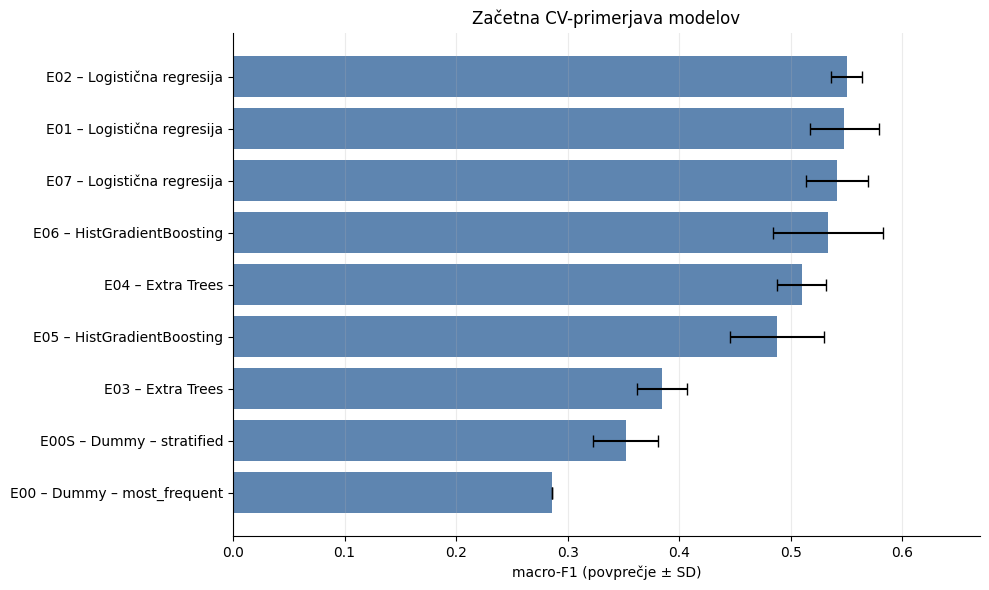

In [23]:
plot_data = successful_experiments.sort_values("macro_f1_mean")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    plot_data["ID"] + " – " + plot_data["Model"],
    plot_data["macro_f1_mean"],
    xerr=plot_data["macro_f1_std"],
    color="#4C78A8",
    alpha=0.9,
    capsize=4,
)
ax.set(title="Začetna CV-primerjava modelov", xlabel="macro-F1 (povprečje ± SD)", ylabel="")
ax.set_xlim(0, min(1.0, max(plot_data["macro_f1_mean"] + plot_data["macro_f1_std"]) * 1.15))
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
best_initial = successful_experiments.iloc[0]
print(
    f"Najboljši začetni poskus je {best_initial['ID']} ({best_initial['Model']}, "
    f"{best_initial['Uravnoteženje']}) z macro-F1 "
    f"{best_initial['macro_f1_mean']:.3f} ± {best_initial['macro_f1_std']:.3f}."
)
print(
    f"Njegov Graduate F1 je {best_initial['f1_graduate_mean']:.3f}, "
    f"Graduate recall pa {best_initial['recall_graduate_mean']:.3f}."
)
print("Zaklenjeni test tudi po tej primerjavi ostaja neuporabljen.")

Najboljši začetni poskus je E02 (Logistična regresija, class_weight=balanced) z macro-F1 0.550 ± 0.014.
Njegov Graduate F1 je 0.327, Graduate recall pa 0.493.
Zaklenjeni test tudi po tej primerjavi ostaja neuporabljen.


### 21. Uglaševanje dveh najboljših družin

Logistična regresija je najboljši začetni model, uravnoteženi HistGradientBoosting pa najboljši nelinearni kandidat. Za vsakega izvedemo `RandomizedSearchCV` z 20 kombinacijami in istimi petimi foldi. Iskanje optimizira izključno `f1_macro`; test ni del iskanja. Logistična regresija hkrati preveri `class_weight`, HistGradientBoosting pa učno hitrost, velikost dreves, regularizacijo, minimalno velikost listov, število iteracij in uteži.

In [25]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV

TUNING_ITERATIONS = 20
TUNING_SPECS = [
    {
        "ID": "T01",
        "Model": "Logistična regresija",
        "Estimator": build_model_pipeline(LogisticRegression(
            max_iter=4000, solver="lbfgs", random_state=RANDOM_STATE
        )),
        "Parametri": {
            "model__C": loguniform(1e-3, 1e2),
            "model__class_weight": [None, "balanced"],
        },
    },
    {
        "ID": "T02",
        "Model": "HistGradientBoosting",
        "Estimator": build_dense_model_pipeline(HistGradientBoostingClassifier(
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=15,
            random_state=RANDOM_STATE
        )),
        "Parametri": {
            "model__learning_rate": loguniform(0.02, 0.20),
            "model__max_iter": randint(100, 301),
            "model__max_leaf_nodes": randint(7, 64),
            "model__min_samples_leaf": randint(10, 61),
            "model__l2_regularization": loguniform(1e-4, 10.0),
            "model__class_weight": [None, "balanced"],
        },
    },
]

tuning_searches = {}
tuning_summary_rows = []
for spec in TUNING_SPECS:
    print(f"Začenjam {spec['ID']}: {spec['Model']} ...")
    started = time.perf_counter()
    try:
        search = RandomizedSearchCV(
            estimator=spec["Estimator"],
            param_distributions=spec["Parametri"],
            n_iter=TUNING_ITERATIONS,
            scoring=PRIMARY_METRIC,
            cv=CV_SPLITTER,
            refit=True,
            random_state=RANDOM_STATE,
            n_jobs=2,
            error_score="raise",
            return_train_score=False,
        )
        search.fit(X_train, y_train)
        elapsed = time.perf_counter() - started
        tuning_searches[spec["ID"]] = search

        detailed_scores = cross_validate(
            search.best_estimator_,
            X_train,
            y_train,
            cv=CV_SPLITTER,
            scoring=PHASE3_SCORING,
            n_jobs=1,
            error_score="raise",
        )
        row = {
            "ID": spec["ID"],
            "Model": spec["Model"],
            "Status": "uspešno",
            "Preizkušenih kombinacij": TUNING_ITERATIONS,
            "Čas (s)": elapsed,
            "Najboljši parametri": search.best_params_,
        }
        for metric in PHASE3_SCORING:
            values = detailed_scores[f"test_{metric}"]
            row[f"{metric}_mean"] = float(np.mean(values))
            row[f"{metric}_std"] = float(np.std(values, ddof=1))
        tuning_summary_rows.append(row)
        print(
            f"{spec['ID']} končan: macro-F1={row['macro_f1_mean']:.3f} "
            f"± {row['macro_f1_std']:.3f}; čas={elapsed:.1f} s"
        )
    except Exception as error:
        elapsed = time.perf_counter() - started
        tuning_summary_rows.append({
            "ID": spec["ID"],
            "Model": spec["Model"],
            "Status": "napaka",
            "Preizkušenih kombinacij": TUNING_ITERATIONS,
            "Čas (s)": elapsed,
            "Napaka": f"{type(error).__name__}: {error}",
        })
        print(f"{spec['ID']} ni uspel: {type(error).__name__}: {error}")

tuning_summary = pd.DataFrame(tuning_summary_rows)
assert len(tuning_summary) == 2
print(f"Uspešno uglašenih kandidatov: {(tuning_summary['Status'] == 'uspešno').sum()} od 2.")

Začenjam T01: Logistična regresija ...


T01 končan: macro-F1=0.558 ± 0.033; čas=13.5 s
Začenjam T02: HistGradientBoosting ...


T02 končan: macro-F1=0.558 ± 0.012; čas=122.0 s
Uspešno uglašenih kandidatov: 2 od 2.


### 22. Rezultati uglaševanja in izbor finalista

Če sta kandidata po `macro-F1` oddaljena največ 0,01, odločimo najprej po manjšem raztrosu med foldi, nato po `balanced accuracy` in F1 razreda `Graduate`. Preprostejši model bi imel prednost šele, če bi bili primerljivi tudi ti kriteriji. Sicer izberemo kandidata z višjim povprečjem. To pravilo uporablja samo učni CV in je določeno pred pogledom na test.

In [26]:
successful_tuning = (
    tuning_summary.loc[tuning_summary["Status"] == "uspešno"]
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)
assert len(successful_tuning) == 2

tuning_comparison_rows = []
for _, row in successful_tuning.iterrows():
    tuning_comparison_rows.append({
        "ID": row["ID"],
        "Model": row["Model"],
        "CV macro-F1": f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}",
        "Balanced accuracy": f"{row['balanced_accuracy_mean']:.3f}",
        "Graduate F1": f"{row['f1_graduate_mean']:.3f}",
        "Graduate recall": f"{row['recall_graduate_mean']:.3f}",
        "Čas iskanja (s)": f"{row['Čas (s)']:.1f}",
        "Najboljši parametri": row["Najboljši parametri"],
    })
show_table(tuning_comparison_rows)

top_row = successful_tuning.iloc[0]
macro_gap = float(successful_tuning["macro_f1_mean"].max() - successful_tuning["macro_f1_mean"].min())
if macro_gap <= 0.01:
    finalist_row = successful_tuning.sort_values(
        ["macro_f1_std", "balanced_accuracy_mean", "f1_graduate_mean"],
        ascending=[True, False, False],
    ).iloc[0]
    finalist_reason = (
        "macro-F1 je znotraj 0,01; odločili so manjši CV-razstros in boljše "
        "sekundarne metrike"
    )
else:
    finalist_row = top_row
    finalist_reason = "izbrano je najvišje povprečje CV macro-F1"

FINALIST_ID = finalist_row["ID"]
FINALIST_SEARCH = tuning_searches[FINALIST_ID]
FINALIST_PIPELINE = FINALIST_SEARCH.best_estimator_
FINALIST_SELECTED_WITHOUT_TEST = True

print(
    f"Finalist: {FINALIST_ID} – {finalist_row['Model']} z macro-F1 "
    f"{finalist_row['macro_f1_mean']:.3f} ± {finalist_row['macro_f1_std']:.3f}."
)
print("Razlog:", finalist_reason + ".")
print("Finalist je izbran brez uporabe zaklenjenega testa.")

ID,Model,CV macro-F1,Balanced accuracy,Graduate F1,Graduate recall,Čas iskanja (s),Najboljši parametri
T01,Logistična regresija,0.558 ± 0.033,0.548,0.321,0.307,13.5,"{'model__C': np.float64(1.1435780278433403), 'model__class_weight': None}"
T02,HistGradientBoosting,0.558 ± 0.012,0.635,0.342,0.547,122.0,"{'model__class_weight': 'balanced', 'model__l2_regularization': np.float64(0.000602521573620386), 'model__learning_rate': np.float64(0.022861967752626437), 'model__max_iter': 187, 'model__max_leaf_nodes': 59, 'model__min_samples_leaf': 45}"


Finalist: T02 – HistGradientBoosting z macro-F1 0.558 ± 0.012.
Razlog: macro-F1 je znotraj 0,01; odločili so manjši CV-razstros in boljše sekundarne metrike.
Finalist je izbran brez uporabe zaklenjenega testa.


## Ugotovitve 3. faze

- Izvedenih je devet začetnih poskusov: dummy `most_frequent` (0,286), dummy `stratified` (0,352), logistična regresija brez/z utežmi (0,548/0,550), Extra Trees brez/z utežmi (0,384/0,510), HistGradientBoosting brez/z utežmi (0,488/0,533) in SMOTENC z logistično regresijo (0,541). Vse vrednosti so povprečni petkratni CV `macro-F1`.
- Razredne uteži so pri začetni logistični regresiji rahlo izboljšale povprečni `macro-F1` in zmanjšale raztros z 0,031 na 0,014. Pri Extra Trees in HistGradientBoosting so uteži izrazito izboljšale rezultat glede na njuni neuteženi različici.
- Navadni SMOTE po one-hot kodiranju ni bil uporabljen. SMOTENC je obravnaval izvorne kategorije in binarne indikatorje manjkajočnosti kot kategorije ter se izvajal samo znotraj učnega dela folda.
- Logistična regresija in HistGradientBoosting sta bila vsak uglašena z 20 naključnimi kombinacijami in petkratnim stratificiranim CV. Oba zaokroženo dosežeta `macro-F1` 0,558, vendar ima HistGradientBoosting manjši raztros (0,012 proti 0,033), višjo `balanced accuracy` (0,635 proti 0,548), višji Graduate F1 (0,342 proti 0,321) in višji Graduate recall (0,547 proti 0,307).
- Po vnaprej zapisanem tie-break pravilu je finalist **T02 – HistGradientBoosting**. Zaklenjeni test še vedno ni bil uporabljen za izračun uspešnosti. `FINALIST_PIPELINE` je prilegan samo na celotnem učnem delu in je pripravljen za enkratno končno oceno v naslednji fazi.

## 4. faza: končna ocena, poročanje in sled poskusov

Finalist je že izbran samo na podlagi učnega CV. Pred odpiranjem testa izvedemo še dve vnaprej načrtovani vsebinski kontroli na učnem delu; njuna rezultata ne spreminjata finalista. Nato test uporabimo enkrat za končno oceno in po tem ne uglašujemo več nobenega parametra.

### 23. Vsebinski kontroli na učnem CV

Kontrola A primerja polni model z zgodnjo različico brez 12 semestrskih in treh drugih potencialno poznejših meritev. Kontrola B doda šest ID-stolpcev, da preveri, ali bi navidezno izboljšanje lahko izviralo iz identifikatorjem podobnih kod. Obe uporabljata že izbrane hiperparametre T02 in iste fold-e.

In [27]:
selected_model_template = clone(FINALIST_PIPELINE.named_steps["model"])
ALL_PREDICTOR_COLUMNS = [column for column in df.columns if column != TARGET_COLUMN]

ablation_specs = [
    {
        "ID": "A01",
        "Različica": "Zgodnja ob vpisu",
        "Features": EARLY_FEATURE_COLUMNS,
        "Pipeline": build_dense_model_pipeline(
            clone(selected_model_template), feature_columns=EARLY_FEATURE_COLUMNS
        ),
    },
    {
        "ID": "A02",
        "Različica": "Polna + 6 ID-stolpcev",
        "Features": ALL_PREDICTOR_COLUMNS,
        "Pipeline": build_dense_model_pipeline(
            clone(selected_model_template), feature_columns=ALL_PREDICTOR_COLUMNS
        ),
    },
]

ablation_rows = []
full_tuned_row = successful_tuning.loc[successful_tuning["ID"] == FINALIST_ID].iloc[0]
ablation_rows.append({
    "ID": FINALIST_ID,
    "Različica": "Polna brez ID (finalist)",
    "Število značilk": len(FULL_FEATURE_COLUMNS),
    "Status": "uspešno",
    "macro_f1_mean": float(full_tuned_row["macro_f1_mean"]),
    "macro_f1_std": float(full_tuned_row["macro_f1_std"]),
    "balanced_accuracy_mean": float(full_tuned_row["balanced_accuracy_mean"]),
    "f1_graduate_mean": float(full_tuned_row["f1_graduate_mean"]),
    "recall_graduate_mean": float(full_tuned_row["recall_graduate_mean"]),
})

for spec in ablation_specs:
    started = time.perf_counter()
    try:
        scores = cross_validate(
            spec["Pipeline"],
            df.loc[X_train.index, spec["Features"]],
            y_train,
            cv=CV_SPLITTER,
            scoring=PHASE3_SCORING,
            n_jobs=1,
            error_score="raise",
        )
        row = {
            "ID": spec["ID"],
            "Različica": spec["Različica"],
            "Število značilk": len(spec["Features"]),
            "Status": "uspešno",
            "Čas (s)": time.perf_counter() - started,
        }
        for metric in PHASE3_SCORING:
            values = scores[f"test_{metric}"]
            row[f"{metric}_mean"] = float(np.mean(values))
            row[f"{metric}_std"] = float(np.std(values, ddof=1))
        ablation_rows.append(row)
    except Exception as error:
        ablation_rows.append({
            "ID": spec["ID"],
            "Različica": spec["Različica"],
            "Število značilk": len(spec["Features"]),
            "Status": "napaka",
            "Čas (s)": time.perf_counter() - started,
            "Napaka": f"{type(error).__name__}: {error}",
        })

ablation_summary = pd.DataFrame(ablation_rows)
assert (ablation_summary["Status"] == "uspešno").all()
ablation_display_rows = []
for _, row in ablation_summary.iterrows():
    ablation_display_rows.append({
        "ID": row["ID"],
        "Različica": row["Različica"],
        "Značilke": int(row["Število značilk"]),
        "CV macro-F1": f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}",
        "Balanced accuracy": f"{row['balanced_accuracy_mean']:.3f}",
        "Graduate F1": f"{row['f1_graduate_mean']:.3f}",
        "Graduate recall": f"{row['recall_graduate_mean']:.3f}",
    })
show_table(ablation_display_rows)
print("Kontroli sta poročani kot ablaciji; finalist T02 ostaja nespremenjen.")

ID,Različica,Značilke,CV macro-F1,Balanced accuracy,Graduate F1,Graduate recall
T02,Polna brez ID (finalist),51,0.558 ± 0.012,0.635,0.342,0.547
A01,Zgodnja ob vpisu,36,0.408 ± 0.007,0.458,0.154,0.293
A02,Polna + 6 ID-stolpcev,57,0.570 ± 0.028,0.644,0.365,0.560


Kontroli sta poročani kot ablaciji; finalist T02 ostaja nespremenjen.


### 24. Sled vseh poskusov

Preglednica združi začetne modele, uglaševanje in vsebinski kontroli. Testni rezultat ni CV-poskus in je zato poročan ločeno.

In [28]:
experiment_log_rows = []
for _, row in experiment_summary.iterrows():
    experiment_log_rows.append({
        "ID": row["ID"],
        "Vrsta": "začetni CV",
        "Model / podatki": row["Model"],
        "Uravnoteženje / opomba": row["Uravnoteženje"],
        "CV macro-F1": (
            f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}"
            if row["Status"] == "uspešno" else "—"
        ),
        "Status / odločitev": row["Status"],
    })
for _, row in tuning_summary.iterrows():
    experiment_log_rows.append({
        "ID": row["ID"],
        "Vrsta": "RandomizedSearchCV",
        "Model / podatki": row["Model"],
        "Uravnoteženje / opomba": "20 kombinacij",
        "CV macro-F1": (
            f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}"
            if row["Status"] == "uspešno" else "—"
        ),
        "Status / odločitev": "finalist" if row["ID"] == FINALIST_ID else "ni izbran",
    })
for _, row in ablation_summary.loc[ablation_summary["ID"].str.startswith("A")].iterrows():
    experiment_log_rows.append({
        "ID": row["ID"],
        "Vrsta": "ablacijski CV",
        "Model / podatki": row["Različica"],
        "Uravnoteženje / opomba": "parametri T02",
        "CV macro-F1": f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}",
        "Status / odločitev": "vsebinska kontrola; ne spremeni finalista",
    })
show_table(experiment_log_rows)
print(f"V sled je vključenih {len(experiment_log_rows)} poskusov oziroma kontrol.")

ID,Vrsta,Model / podatki,Uravnoteženje / opomba,CV macro-F1,Status / odločitev
E00,začetni CV,Dummy – most_frequent,brez,0.286 ± 0.000,uspešno
E00S,začetni CV,Dummy – stratified,brez,0.352 ± 0.029,uspešno
E01,začetni CV,Logistična regresija,brez,0.548 ± 0.031,uspešno
E02,začetni CV,Logistična regresija,class_weight=balanced,0.550 ± 0.014,uspešno
E03,začetni CV,Extra Trees,brez,0.384 ± 0.022,uspešno
E04,začetni CV,Extra Trees,class_weight=balanced,0.510 ± 0.022,uspešno
E05,začetni CV,HistGradientBoosting,brez,0.488 ± 0.042,uspešno
E06,začetni CV,HistGradientBoosting,class_weight=balanced,0.533 ± 0.049,uspešno
E07,začetni CV,Logistična regresija,SMOTENC,0.541 ± 0.028,uspešno
T01,RandomizedSearchCV,Logistična regresija,20 kombinacij,0.558 ± 0.033,ni izbran


V sled je vključenih 13 poskusov oziroma kontrol.


### 25. Enkratna končna ocena na zaklenjenem testu

Naslednja celica je edino mesto, kjer izbrani model napove nespremenjeni `X_test` za izračun končnih metrik. Če jo v isti seji zaženemo še enkrat, se namenoma ustavi. Poznejša permutacijska pomembnost uporablja že zaklenjeni model samo za post-hoc razlago; po tej točki se model in hiperparametri ne spreminjajo več.

In [29]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, precision_score,
)

if globals().get("TEST_EVALUATED", False):
    raise RuntimeError("Zaklenjeni test je bil v tej seji že ocenjen.")

test_predictions = FINALIST_PIPELINE.predict(X_test)
TEST_EVALUATED = True

test_accuracy = accuracy_score(y_test, test_predictions)
test_balanced_accuracy = balanced_accuracy_score(y_test, test_predictions)
test_macro_f1 = f1_score(
    y_test, test_predictions, labels=CLASS_ORDER, average="macro", zero_division=0
)
test_report = classification_report(
    y_test, test_predictions, labels=CLASS_ORDER, output_dict=True, zero_division=0
)
test_confusion = confusion_matrix(y_test, test_predictions, labels=CLASS_ORDER)
test_confusion_normalized = confusion_matrix(
    y_test, test_predictions, labels=CLASS_ORDER, normalize="true"
)

test_summary_rows = [
    {"Metrika": "Accuracy", "Vrednost": f"{test_accuracy:.3f}"},
    {"Metrika": "Balanced accuracy", "Vrednost": f"{test_balanced_accuracy:.3f}"},
    {"Metrika": "Macro-F1", "Vrednost": f"{test_macro_f1:.3f}"},
]
show_table(test_summary_rows)

test_class_rows = []
for target_class in CLASS_ORDER:
    metrics = test_report[target_class]
    test_class_rows.append({
        "Razred": target_class,
        "Precision": f"{metrics['precision']:.3f}",
        "Recall": f"{metrics['recall']:.3f}",
        "F1": f"{metrics['f1-score']:.3f}",
        "Support": int(metrics["support"]),
    })
show_table(test_class_rows)
display(pd.DataFrame(
    test_confusion,
    index=[f"Dejanski {label}" for label in CLASS_ORDER],
    columns=[f"Napovedani {label}" for label in CLASS_ORDER],
))
assert TEST_EVALUATED and len(test_predictions) == len(y_test) == 375
print("Končna testna napoved je bila izvedena enkrat; izbor modela je zaključen.")

Metrika,Vrednost
Accuracy,0.685
Balanced accuracy,0.556
Macro-F1,0.528


Razred,Precision,Recall,F1,Support
Dropout,0.878,0.740,0.803,281
Enrolled,0.362,0.560,0.440,75
Graduate,0.318,0.368,0.341,19


,Napovedani Dropout,Napovedani Enrolled,Napovedani Graduate
Dejanski Dropout,208,63,10
Dejanski Enrolled,28,42,5
Dejanski Graduate,1,11,7


Končna testna napoved je bila izvedena enkrat; izbor modela je zaključen.


### 26. 95-% bootstrap interval za testni `macro-F1`

Interval dobimo z 5.000 ponovitvami parnega vzorčenja že izračunanih `(dejanski razred, napoved)` parov. Modela ne prilegamo ponovno in ne spreminjamo. Ker je v testu samo 19 primerov `Graduate`, interval pričakovano odraža precejšnjo negotovost.

In [30]:
BOOTSTRAP_REPEATS = 5000
bootstrap_rng = np.random.default_rng(RANDOM_STATE)
y_test_array = np.asarray(y_test)
test_predictions_array = np.asarray(test_predictions)
bootstrap_macro_f1 = np.empty(BOOTSTRAP_REPEATS)

for repeat in range(BOOTSTRAP_REPEATS):
    sample_indices = bootstrap_rng.integers(0, len(y_test_array), size=len(y_test_array))
    bootstrap_macro_f1[repeat] = f1_score(
        y_test_array[sample_indices],
        test_predictions_array[sample_indices],
        labels=CLASS_ORDER,
        average="macro",
        zero_division=0,
    )

bootstrap_ci_low, bootstrap_ci_high = np.quantile(bootstrap_macro_f1, [0.025, 0.975])
print(
    f"Testni macro-F1 = {test_macro_f1:.3f}; "
    f"95-% bootstrap interval = [{bootstrap_ci_low:.3f}, {bootstrap_ci_high:.3f}]."
)
assert 0 <= bootstrap_ci_low <= test_macro_f1 <= bootstrap_ci_high <= 1

Testni macro-F1 = 0.528; 95-% bootstrap interval = [0.451, 0.601].


### 27. Matrika zamenjav in F1 po razredih

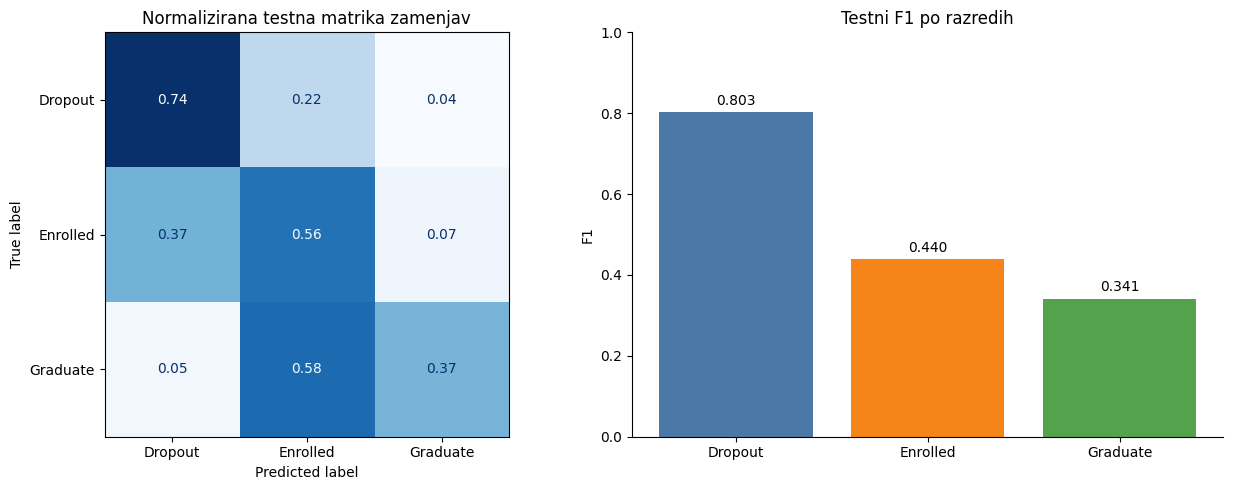

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_normalized,
    display_labels=CLASS_ORDER,
).plot(ax=axes[0], cmap="Blues", values_format=".2f", colorbar=False)
axes[0].set_title("Normalizirana testna matrika zamenjav")

class_f1_values = [test_report[label]["f1-score"] for label in CLASS_ORDER]
bars = axes[1].bar(CLASS_ORDER, class_f1_values, color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].bar_label(bars, labels=[f"{value:.3f}" for value in class_f1_values], padding=3)
axes[1].set(title="Testni F1 po razredih", ylabel="F1", ylim=(0, 1))
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 28. Permutacijska pomembnost finalista

Po zaklenitvi modela izračunamo post-hoc permutacijsko pomembnost izvornih 51 stolpcev glede na padec testnega `macro-F1` v 20 ponovitvah. Rezultat je opisni pripomoček in ne vpliva več na izbor modela. Negativna ali skoraj ničelna pomembnost pomeni, da permutacija na tem majhnem testu ni škodila; pomembnosti niso dokaz vzročnosti.

Stolpec,Padec macro-F1,SD
Curricular units 1st sem (approved),0.0707,0.0300
Curricular units 2nd sem (approved),0.0492,0.0240
Tuition fees up to date,0.0314,0.0172
Age at enrollment,0.0242,0.0185
Curricular units 2nd sem (grade),0.0169,0.0239
Curricular units 1st sem (credited),0.0140,0.0051
Previous qualification (grade),0.0136,0.0119
Curricular units 1st sem (evaluations),0.0125,0.0164
Curricular units 2nd sem (evaluations),0.0102,0.0103
Logical reasoning test score,0.0102,0.0132


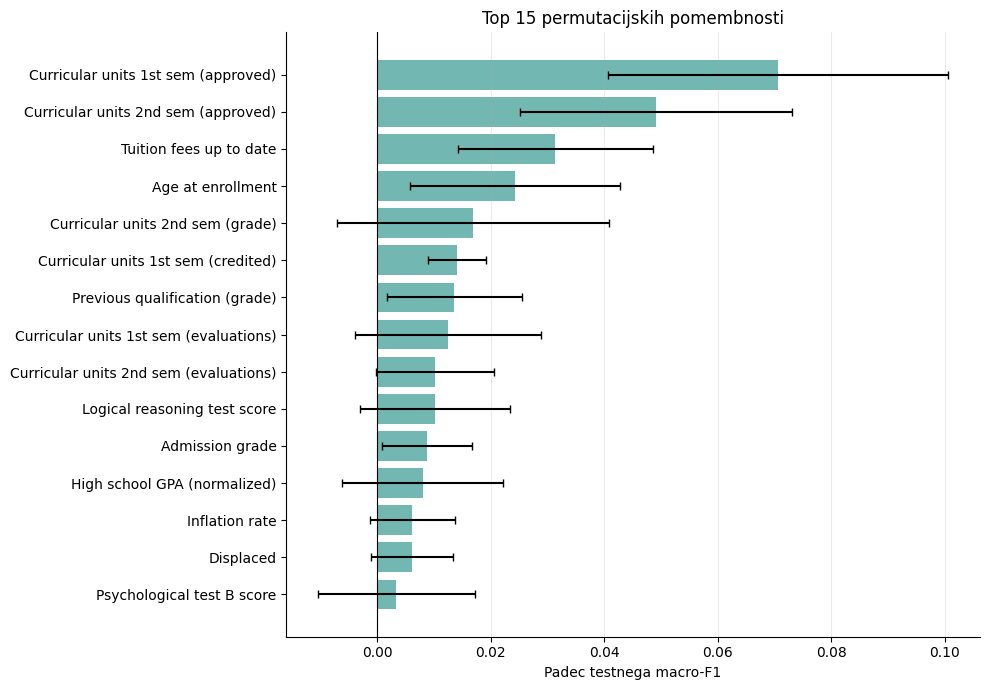

Pomembnosti so izračunane po končnem izboru in niso uporabljene za uglaševanje.


In [32]:
from sklearn.inspection import permutation_importance

PERMUTATION_REPEATS = 20
permutation_result = permutation_importance(
    FINALIST_PIPELINE,
    X_test,
    y_test,
    scoring=PRIMARY_METRIC,
    n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=2,
)
importance_summary = pd.DataFrame({
    "Stolpec": X_test.columns,
    "Povprečni padec macro-F1": permutation_result.importances_mean,
    "SD": permutation_result.importances_std,
}).sort_values("Povprečni padec macro-F1", ascending=False, ignore_index=True)
top_importance = importance_summary.head(15).copy()
show_table([
    {
        "Stolpec": row["Stolpec"],
        "Padec macro-F1": f"{row['Povprečni padec macro-F1']:.4f}",
        "SD": f"{row['SD']:.4f}",
    }
    for _, row in top_importance.iterrows()
])

plot_importance = top_importance.sort_values("Povprečni padec macro-F1")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    plot_importance["Stolpec"],
    plot_importance["Povprečni padec macro-F1"],
    xerr=plot_importance["SD"],
    color="#72B7B2",
    capsize=3,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Top 15 permutacijskih pomembnosti", xlabel="Padec testnega macro-F1", ylabel="")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("Pomembnosti so izračunane po končnem izboru in niso uporabljene za uglaševanje.")

## Končni sklep in omejitve

### Končni rezultat

Finalist je uglašeni **HistGradientBoosting T02** z `class_weight='balanced'`, `learning_rate=0,02286`, 187 največ iteracijami, 59 listi, `min_samples_leaf=45` in `l2_regularization=0,000603`. Izbran je bil samo na učnem delu: njegov petkratni CV `macro-F1` je **0,558 ± 0,012**.

Na enkrat uporabljenem zaklenjenem testu doseže:

- **macro-F1 0,528**, 95-% bootstrap interval **[0,451, 0,601]**;
- **balanced accuracy 0,556** in navadno accuracy 0,685;
- F1 0,803 za `Dropout`, 0,440 za `Enrolled` in 0,341 za `Graduate`;
- recall 0,740 za `Dropout`, 0,560 za `Enrolled` in 0,368 za `Graduate`.

Testni `macro-F1` je nekoliko nižji od CV-povprečja, vendar leži znotraj negotovosti, ki jo nakazuje širok bootstrap interval. Accuracy je nižja od deleža večinskega razreda, kar je pričakovana cena bolj uravnoteženega napovedovanja; zato accuracy ni bila uporabljena kot glavna metrika. Model pravilno prepozna 7 od 19 primerov `Graduate`; 11 jih zamenja za `Enrolled`, enega pa za `Dropout`.

### Vsebinski kontroli

- Zgodnja različica s 36 značilkami doseže samo **0,408 ± 0,007 CV macro-F1**, polna različica po 2. semestru pa 0,558 ± 0,012. Končni model je zato model za napoved **po 2. semestru**, ne sistem zgodnjega opozarjanja ob vpisu.
- Dodatek šestih ID-stolpcev dvigne CV `macro-F1` na **0,570 ± 0,028**, vendar poveča raztros in prinaša tveganje naključne povezave oziroma uhajanja. Ker so skoraj enolični in nimajo jasne prenosljive semantike, ostajajo izločeni. Rezultat A02 je poročan kot opozorilna ablacija, ne kot razlog za spremembo finalista.

### Razlaga modela

Največji povprečni padec testnega `macro-F1` pri permutaciji povzročijo `Curricular units 1st sem (approved)` (0,0707), `Curricular units 2nd sem (approved)` (0,0492), `Tuition fees up to date` (0,0314) in `Age at enrollment` (0,0242). Pomembnost semestrskih značilk je skladna z razliko med polnim in zgodnjim modelom. To so napovedne povezave, ne dokazi vzročnega vpliva.

### Omejitve

- Test vsebuje samo 19 primerov `Graduate`, zato sta ocena tega razreda in skupni `macro-F1` negotova.
- V podatkih manjka 7,87 % napovednih celic. Imputacija je izvedena brez uhajanja znotraj pipelinea, vendar lahko izgubi del informacije; indikatorji manjkajočnosti to le delno ublažijo.
- Brez uradnega šifranta ni mogoče potrditi vsebinske veljavnosti vseh redkih kategoričnih kod.
- Čas merjenja nekaterih dodatnih spremenljivk ni dokumentiran. Zgodnja različica je zato konservativna vsebinska ocena.
- Permutacijska pomembnost je izračunana post-hoc na zaklenjenem testu po končnem izboru modela. Ni bila uporabljena za uglaševanje, vendar ostaja odvisna od tega majhnega vzorca.
- Rezultat še ni potrjen na zunanji podatkovni množici, zato ne dokazuje prenosljivosti na druge generacije ali ustanove.

Vsi začetni, slabši, uravnoteženi, SMOTENC, uglašeni in ablacijski poskusi so ohranjeni v sledilni preglednici. Test ni vplival na izbor modela ali hiperparametrov.